# Neural Network from Scratch

## Load Libraries

In [1]:
import numpy as np # for implementing Neural Network
import pandas as pd # for data loading
import matplotlib.pyplot as plt # for visualization
import seaborn as sns # for visualization

from sklearn.preprocessing import StandardScaler # for data scaling
from sklearn.model_selection import train_test_split # for train/test split
from sklearn.metrics import mean_absolute_error
import tensorflow as tf # for comparing

## Get Data

In [2]:
df = pd.read_csv("car_purchasing.csv", encoding='ISO-8859-1')
df.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


## Feature Selection & Encoding + Normalization

Feature selecting

In [3]:
# customer name, customer e-mail and country columns can be dropped
selected_features = df.describe().columns # getting only numerical features
                                               # last feature is our target
display(selected_features)

Index(['gender', 'age', 'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='str')

Storing data with only selected features

In [4]:
df_selected_features = df[selected_features] # data only with selected features
df_selected_features.head()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


Data Analysis

In [5]:
df_selected_features.describe()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


Data looks clean, let's check for missing values and duplicates

In [6]:
df_selected_features.isna().sum()

gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [7]:
df_selected_features.duplicated().sum()

0

Data is clean.

We have 1 categorical feature (`gender`) but it's already encoded into binary format which works with our future model.

Next step is to scale our data.

In [8]:
X = df_selected_features.iloc[:, :-1] # all rows, all columns except last column
y = df_selected_features.iloc[:, -1] # all rows, last column
display(X.head(), y.head())

,gender,age,annual Salary,credit card debt,net worth
0,0,41.851720,62812.09301,11609.380910,238961.2505
1,0,40.870623,66646.89292,9572.957136,530973.9078
2,1,43.152897,53798.55112,11160.355060,638467.1773
3,1,58.271369,79370.03798,14426.164850,548599.0524
4,1,57.313749,59729.15130,5358.712177,560304.0671


0    35321.45877
1    45115.52566
2    42925.70921
3    67422.36313
4    55915.46248
Name: car purchase amount, dtype: float64

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X) # fit scaler and transform our data
y = y / y.max() # scale target to be between 0 and 1
print(X[:5], )
print(y[:5])

[[-1.01207287 -0.55074911  0.05857619  0.57427133 -1.11046945]
 [-1.01207287 -0.67383422  0.38657041 -0.0099515   0.57392937]
 [ 0.98807114 -0.38750768 -0.71236095  0.4454518   1.19397625]
 [ 0.98807114  1.50920564  1.47479358  1.38236908  0.67559542]
 [ 0.98807114  1.38906581 -0.20511086 -1.21896218  0.74311275]]
0    0.441518
1    0.563944
2    0.536571
3    0.842780
4    0.698943
Name: car purchase amount, dtype: float64


In [10]:
X, y = np.array(X, dtype="float32"), np.array(y, dtype="float32") 
X.dtype, y.dtype

(dtype('float32'), dtype('float32'))

## Visualize Data

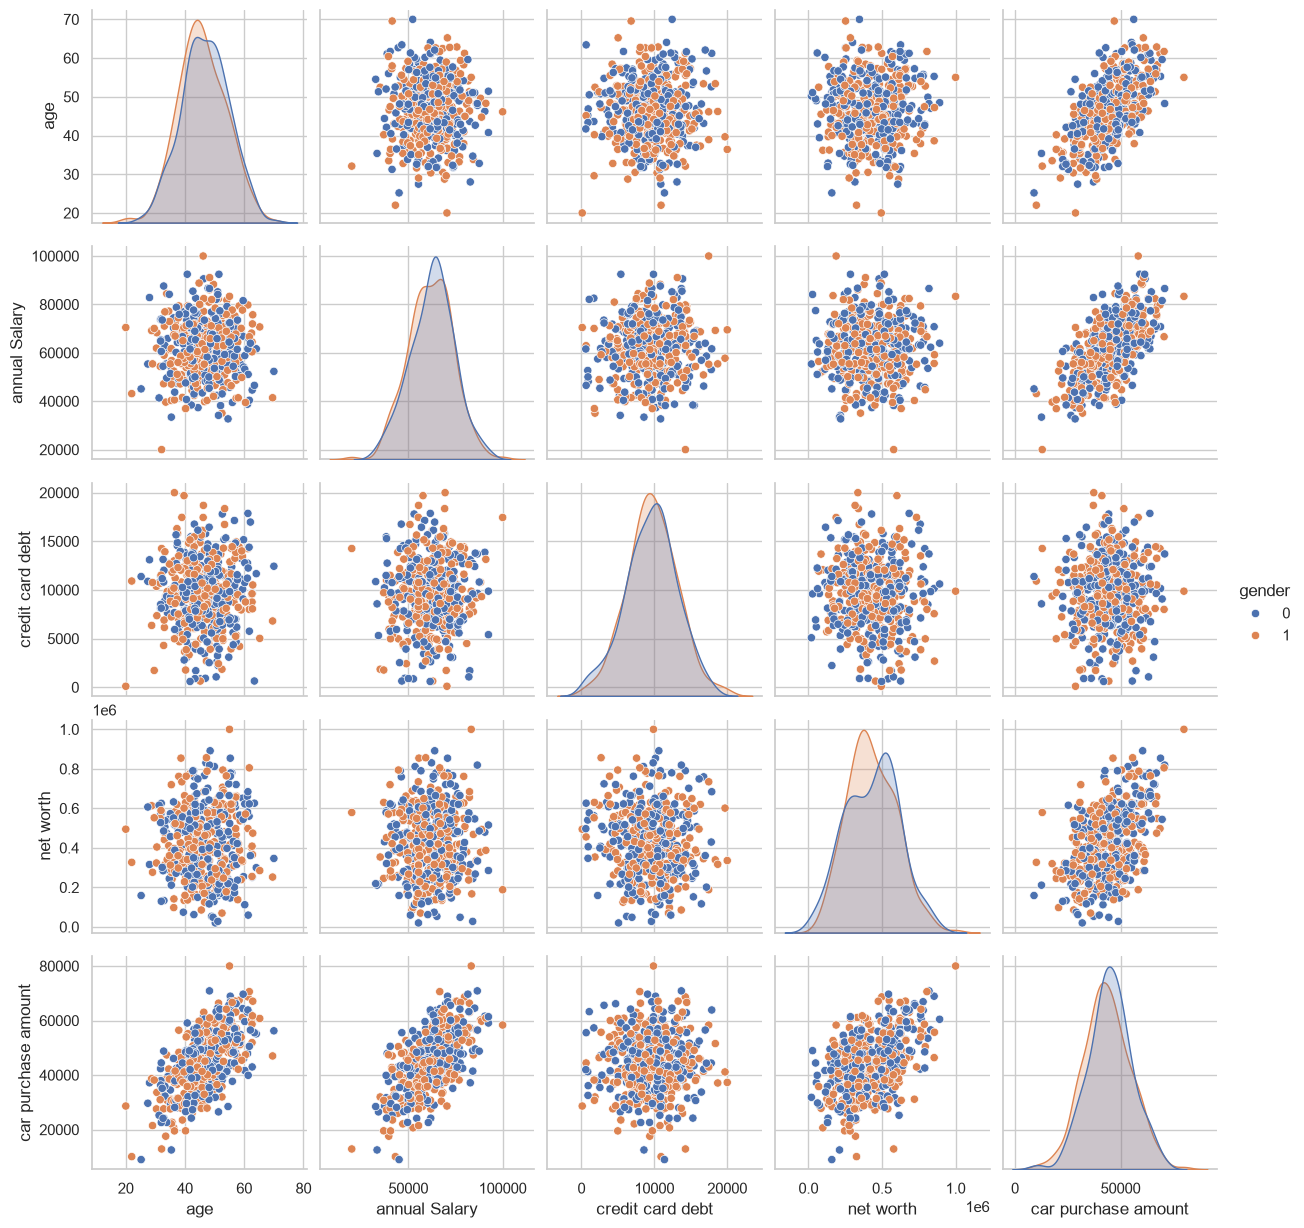

In [11]:
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook"
)

sns.pairplot(df_selected_features, hue='gender')
plt.show()

We can see that features (`age`, `annual Salary`, `net worth`) have visible correlation with our target variable (`car purchase amount`)

## Custom Neural Network Implementation

In [12]:
class Scalar():

  def __init__(self, data: float, _children=(), label=''):
    """
    Scalar object that stores single value
    Parameters:
      data (float): any number in float format
      label (str): optional, name for the object
    """
    self.data = data
    self.grad = 0.0 # gradient value; computed when back propagation is called
    self._backward = lambda: None # function to perform back propagation, actual function assigns during the computations
    self._prev = set(_children) # set of previous operations (instances of Scalar)
    self.label = label # label for Scalar if present

  def __get_scalar__(self, other: float):
    """
    Function to make other be instance of Scalar
    Parameters:
      other (float): any float value
    Returns:
      Scalar: creates new instance of scalar by passing {other} value
              or returns other if it is already instance of Scalar
    """
    return other if isinstance(other, Scalar) else Scalar(other)

  def __add__(self, other: float):
    """
    Performs addition operation for 2 instances of Scalar
    Computes backward function for the current operation
    Parameters:
      other (float | Scalar): number to be added to
    Returns:
      Scalar: new Scalar instance that contains result of the addition
    """
    other = self.__get_scalar__(other) # check if other is Scalar
    out = Scalar(self.data + other.data, (self, other)) # computes the result of addition and creates new instance of Scalar

    def backward(): # create function that performs back propagation
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = backward # assigns created function to the result Scalar object for fututre chain
    return out # returns result of computation in form of Scalar

  def __mul__(self, other: float):
    """
    Performs multiplication operation for 2 instances of Scalar
    Computes backward function for the current operation
    Parameters:
      other (float | Scalar): number to be multiplied
    Returns:
      Scalar: new Scalar instance that contains result of the multiplication
    """
    other = self.__get_scalar__(other)
    out = Scalar(self.data * other.data, (self, other))

    def backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = backward
    return out

  def __pow__(self, other: float | int):
    """
    Performs raising to power - {other} for the self object (self^other)
    Computes backward function for the current operation
    Parameters:
      other (float | int): number to be raised to
    Returns:
      Scalar: new Scalar instance that contains result of raising to power
    """
    assert isinstance(other, (int, float)) # check for number
    out = Scalar(self.data**other, (self, ))

    def backward():
      self.grad += other * (self.data**(other-1.0)) * out.grad # derivative for power rule
    out._backward = backward

    return out

  def tanh(self):
    """
    Performs tanh activation for self object
    Computes backward function for the current operation
    Returns:
      Scalar: new Scalar instance that contains result of the computation
    """
    x = self.data
    t = (np.exp(2.0*x) - 1.0)/(np.exp(2.0*x) + 1.0) # formula for computing tanh
    out = Scalar(t, (self, ))

    def backward():
      self.grad += (1.0 - t**2.0) * out.grad # derivative of tanh function formula
    out._backward = backward

    return out

  def relu(self):
    """
    Performs relu activation for self object
    Computes backward function for the current operation
    Returns:
      Scalar: new Scalar instance that contains result of the computation
    """
    x = self.data
    res = x if x > 0 else 0.0 # formula for computing relu
    out = Scalar(res, (self, ))

    def backward():
      self.grad += (1.0 if x > 0 else 0.0) * out.grad # derivative formula for relu
    out._backward = backward

    return out

  def softplus(self):
    """
    Performs softplus activation for self object
    Computes backward function of the current operation
    Returns:
      Scalar: new Scalar object instance that contains result of computation
    """
    x = self.data
    out_data = np.log1p(np.exp(x))  # stable-ish for moderate x
    out = Scalar(out_data, (self,))

    def _backward():
        sig = 1.0 / (1.0 + np.exp(-x)) # derivative: sigmoid(x) = 1 / (1 + exp(-x))
        self.grad += sig * out.grad

    out._backward = _backward
    return out

  def backward(self):
    """
    Performs backward computing to get gradients with respect of current self
    Builds topological order of instances: (gradient chain)
    calls _backward function for each node to compute gradients
    """
    topo = [] # a list to store all nodes in the right order
    seen = set() # a set to check whether node has been checked already

    def build_topo(v: Scalar) -> None:
      """
      Function to build topological order for Scalars
      The last instance would be self
      Creates a chain of instances for gradient computation
      Parameters:
        v (Scalar): Scalar object which is the object whose derivative would be computed with respect of each child
      """
      if v not in seen: # if Scalar hasn't been checked yet, then recursively check its children
        seen.add(v) # add current Scalar to seen to prevent repetition
        for child in v._prev: # for each child of current node recursively walk through
          build_topo(child)
        topo.append(v) # append current node to topological list

    build_topo(self) # calling function on current node
    self.grad = 1.0 # setting grad to 1, derivative of self with respect to self is 1
    for node in reversed(topo): # reversed, because the last node has to be first for back propogation
      node._backward()

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1.0

  def __neg__(self):
    return self * -1.0

  def __sub__(self, other):
    return self + (-other)

  def __repr__(self):
    return f"Scalar(data={self.data})"


class Neuron():
  def __init__(self, nin):
    """
    Initialise Neuron
    Parameters:
      nin: (int): number of scalar values in this neuron
    """
    self.nin = nin
    self.w = np.array([Scalar(value[0] * np.sqrt(2.0 / nin)) for value in np.random.randn(nin).reshape(-1, 1)]) # randomly generated weights
    self.b = Scalar(0.0) # bias is set to 0

  def f(self, X: np.array) -> np.array:
    """
    Main function for predicting: y = wx + b
    Parameters:
      X (np.array): train data, excluding y
    Returns:
      np.array: Predictions for train data
    """
    return X.dot(self.w) + self.b

  def __call__(self, X: np.array, activation: str = 'linear') -> np.array:
    """
    Performs computing of predictions and activation for this neuron
    Parameters:
      X (np.array): train data
      activation (str): activation function (linear by default)
    Returns:
      np.array: predictions with activations
    """
    result = self.f(X) # basic matrix multiplication, result is (batch_size,) array of Scalars
    if activation == 'linear':
      activated_result = np.array([g for g in result]) # activation function for each scalar
    elif activation == 'relu':
      activated_result = np.array([g.relu() for g in result]) # activation function for each scalar
    elif activation == 'tanh':
      activated_result = np.array([g.tanh() for g in result]) # activation function for each scalar
    elif activation == 'softplus':
      activated_result = np.array([g.softplus() for g in result]) # activation function for each scalar
    return activated_result # Returns (batch_size,) array of Scalars

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the neuron, weights and bias
    Returns:
      np.array: combination of all parameters
    """
    return np.concatenate([self.w, np.array([self.b])], axis=0)

  def __repr__(self):
    return f"Neuron(nin={self.nin})"


class Layer():
  def __init__(self, n_in: int, n_out:int, name='dense_layer', activation='linear'):
    """
    Initialise layer of the model
    Paramaters:
      n_in (int): number of neurons in this layer
      n_out (int): number of neurons for output
      name (str): name for this layer
      activation (str): activation function for each neuron, default - linear
    """
    self.n_in = n_in
    self.n_out = n_out
    self.neurons = [Neuron(self.n_in) for _ in range(self.n_out)] # generate number of neurons in the layer
    self.activation = activation
    self.name = name # name of the layer

  def __call__(self, X: np.array) -> np.array:
    """
    Calls each neuron with X
    Each n(X) returns a (batch_size,) array of Scalar objects.
    Parameters:
      X (np.array): train data
    Returns:
      np.array: array of the predictions from each neuron
    """
    outs = [n(X, activation=self.activation) for n in self.neurons] # outs is a list of n_out (batch_size,) arrays
    return np.column_stack(outs) # Stacks into a (batch_size, n_out) array of Scalar objects

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the layer, weights and bias
    Gets parameters from each Neuron and returns them as np.array
    Returns:
      np.array: combination of all parameters
    """
    return np.array([p for neuron in self.neurons for p in neuron.parameters()]) # return all parameters of each neuron

  def __repr__(self):
    return f"Layer(n_in={self.n_in}, n_out={self.n_out}, activation={self.activation}, name={self.name})"

class NeuralNetwork:
  def __init__(self, sequential: list):
    """
    Initialise Neural Network
    Parameters:
      sequential (list): structure of the neural network, example:
                        [
                          Layer(n_in=10, n_out=16, activation='relu'),
                          Layer(n_in=16, n_out=1, activation='linear')
                        ]
      n_in: how many neurons in the layer; for first layer n_in should number of features in the data
      n_out: how many neurons this layer should produce
      activation: 'linear' is default, 'tanh', 'relu', 'softplus' are implemented.
    """
    self.epochs = 10
    self.sequential = sequential # Layers structure
    self.loss_history = []

  def zero_grad(self):
    """
    Sets gradient of all params to 0
    """
    for p in self.parameters():
      p.grad = 0.0

  def __call__(self, X) -> np.array:
    """
    Performs a forward pass through the network.
    Parameters:
      X (np.array): train data
    Returns:
      np.array: current predictions
    """
    # Assumes layers are already specified
    if not self.sequential:
      raise RuntimeError("NeuralNetwork layers have not been built")

    current_input = X
    for layer in self.sequential:
      current_input = layer(current_input)
    return current_input # Final output of the network, (batch_size, 1) array of Scalars

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the Neural Network, weights and bias
    Returns:
      np.array: combination of all parameters
    """
    params = []
    for layer in self.sequential:
        params.extend(layer.parameters())
    return np.array(params)

  def fit(
      self,
      X:np.array, y:np.array,
      learning_rate:float=0.01,
      epochs:int=10,
      batch_size:int=32
      ) -> np.array:
    """
    Main function to train neural network on the data provided
    Parameters:
      X (np.array): train data
      y (np.array): true labels
      learning_rate (float): step size for gradient descent
      epochs (int): number of iterations for training
      batch_size (int): number of records per batch
    Returns:
      np.array: final predictions
    """
    X_copy = np.copy(X) # copy data to prevent changes to original
    self.epochs = epochs # set epochs

    # Clear results from any previous call to fit().
    self.loss_history = []

    N = X_copy.shape[0] # number of samples in our data

    # Convert target values into Scalar objects.
    y_target_scalars = np.array(
        [Scalar(float(value)) for value in y]
    ).reshape(-1, 1)

    for epoch in range(epochs):

        # Shuffle training samples at the beginning of each epoch.
        indices = np.random.permutation(N)
        X_shuf = X_copy[indices]
        y_shuf = y_target_scalars[indices]

        # Accumulate the total squared error across all samples.
        epoch_squared_error = 0.0
        samples_seen = 0

        for start in range(0, N, batch_size):
            # start is the index that corresponds to the beginning of the current batch
            # end is the index that corresponds to the last record of this batch

            end = start + batch_size

            X_batch = X_shuf[start:end]
            y_batch = y_shuf[start:end]

            B = len(X_batch)

            # Forward propagation.
            y_pred = self(X_batch)

            # Calculate batch MSE.
            diff = y_batch - y_pred
            squared = [value**2 for value in diff.flatten()]

            loss = (
                sum(squared, Scalar(0.0))
                * (1.0 / B)
            )

            # Backpropagation.
            self.zero_grad()
            loss.backward()

            # Gradient-descent parameter update.
            for parameter in self.parameters():
                parameter.data += -learning_rate * parameter.grad

            # loss.data is the batch mean, so multiply by B to
            # recover the sum of squared errors for this batch.
            epoch_squared_error += loss.data * B
            samples_seen += B

        # Calculate the sample-weighted MSE for the complete epoch.
        epoch_loss = epoch_squared_error / samples_seen

        self.loss_history.append(epoch_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"--- loss: {epoch_loss:.6f}"
        )

  def predict(self, X_test: np.array) -> np.array:
    """
    Predicts result based on data fitted, number of features should be the same as for training
    Parameters:
      X_test (np.array): array of data for predictions, X_test.shape[1] should == X_train.shape[1]
    Returns:
      np.array: 1D array of predicitons
    """
    y_pred = self(X_test) # getting predictions
    y_pred = np.array([prediction.data for prediction in y_pred.flatten()]) # flattering array to make it 1D and
                                                                            # extracting only data from Scalar
    return y_pred

  def __repr__(self):
    layers_repr = "\n".join(str(layer) for layer in self.sequential)
    return f"NeuralNetwork(sequential=[\n{layers_repr}\n])"

## Train/Test Data Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 5), (100, 5), (400,), (100,))

## Fitting Custom Neural Network

In [14]:
np.random.seed(42)
sequential = [
    Layer(n_in=X_train.shape[1], n_out=16, activation='tanh', name='Hidden_Dense_1'),
    Layer(n_in=16, n_out=16, activation='relu', name='Hidden_Dense_2'),
    Layer(n_in=16, n_out=32, activation='relu', name='Hidden_Dense_3'),
    Layer(n_in=32, n_out=8, activation='softplus', name='Hidden_Dense_4'),
    Layer(n_in=8, n_out=1, activation='linear', name='Output_layer'),
]

custom_nn = NeuralNetwork(sequential=sequential)
custom_nn.fit(X_train, y_train, epochs=10, learning_rate=0.001)

Epoch 1/10 --- loss: 0.179775
Epoch 2/10 --- loss: 0.160660
Epoch 3/10 --- loss: 0.147446
Epoch 4/10 --- loss: 0.137820
Epoch 5/10 --- loss: 0.129897
Epoch 6/10 --- loss: 0.123104
Epoch 7/10 --- loss: 0.117123
Epoch 8/10 --- loss: 0.111947
Epoch 9/10 --- loss: 0.107344
Epoch 10/10 --- loss: 0.102964


In [15]:
print(custom_nn)

NeuralNetwork(sequential=[
Layer(n_in=5, n_out=16, activation=tanh, name=Hidden_Dense_1)
Layer(n_in=16, n_out=16, activation=relu, name=Hidden_Dense_2)
Layer(n_in=16, n_out=32, activation=relu, name=Hidden_Dense_3)
Layer(n_in=32, n_out=8, activation=softplus, name=Hidden_Dense_4)
Layer(n_in=8, n_out=1, activation=linear, name=Output_layer)
])


## Train tf.Keras Model with the Same Parameters

In [16]:
np.random.seed(42)
keras_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='tanh'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(8, activation='softplus'),
    tf.keras.layers.Dense(1, activation='linear'),
])

keras_model.summary()

keras_model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=['mse']
)

keras_loss_history = keras_model.fit(X_train, y_train, epochs=10, batch_size=32)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1417 - mse: 0.1417
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1104 - mse: 0.1104 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0882 - mse: 0.0882 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0725 - mse: 0.0725 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0610 - mse: 0.0610 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0526 - mse: 0.0526 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0466 - mse: 0.0466 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0422 - mse: 0.0422 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0390 - mse: 0.0390 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0366 - mse: 0.0366 


## Getting & Comparing Predicitons

In [17]:
y_pred_custom = custom_nn.predict(X_test)
y_pred_keras = keras_model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [18]:
custom_mae = mean_absolute_error(y_test, y_pred_custom)
keras_mae = mean_absolute_error(y_test, y_pred_keras)
print(f"Custom Neural Network MAE: {custom_mae:.4f}")
print(f"Keras Neural Network MAE: {keras_mae:.4f}")

Custom Neural Network MAE: 0.2352
Keras Neural Network MAE: 0.1526


In [19]:
custom_real_error = custom_mae * 80000 
keras_real_error = keras_mae * 80000
print(f"Custom Neural Network Real Error: ${custom_real_error:.2f}")
print(f"Keras Neural Network Real Error: ${keras_real_error:.2f}")

Custom Neural Network Real Error: $18814.24
Keras Neural Network Real Error: $12206.21


__Loss curves of Models__

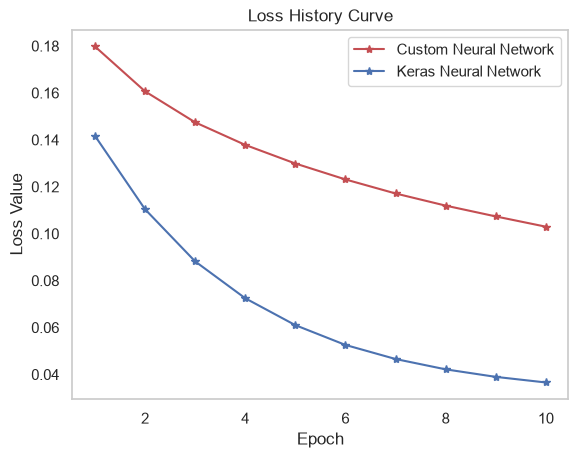

In [20]:
def plot_loss_history(epochs, loss_history_1, loss_history_2):
  plt.plot(epochs, loss_history_1, '*-r')
  plt.plot(epochs, loss_history_2, '*-b')

  plt.title(f"Loss History Curve")
  plt.xlabel('Epoch')
  plt.ylabel('Loss Value')
  plt.legend(['Custom Neural Network', 'Keras Neural Network'])
  plt.grid()
  plt.show()

epochs = np.arange(1, 11)
plot_loss_history(epochs, custom_nn.loss_history, keras_loss_history.history['loss'])

## Conclusion

The Custom Neural Network from Scratch successfully learned a regression task using the [Kaggle car-sales dataset](https://www.kaggle.com/datasets/yashpaloswal/ann-car-sales-price-prediction?select=car_purchasing.csv).

I compared it with a `tensorflow.keras` model using the same neural-network structure, batch size, number of epochs, learning rate and SGD optimiser. However, this was not a fully controlled benchmark, so the results should be treated as a practical comparison rather than proof that both implementations are equivalent.

### Test results

- **Custom Neural Network MAE:** 0.2352
- **Keras Neural Network MAE:** 0.1526
- **Custom Neural Network MAE on the original price scale:** $18,814.24
- **Keras Neural Network MAE on the original price scale:** $12,206.21
- **Maximum price in the dataset:** $80,000

The custom model produced a higher error on unseen data. This suggests that the custom model has higher variance and does not generalise as well as the Keras implementation.

The result does not prove that the custom network is ready for real price prediction. It shows that the implementation can learn a regression task, while also showing where it needs improvement.

## Summary

I implemented a regression neural network from scratch to understand what happens behind high-level libraries such as Keras.

The main network logic was written in plain Python. I created a custom `Scalar` class with automatic differentiation and implemented forward propagation, backpropagation, weight updates, Mean Squared Error, mini-batch training and SGD. I also added the `linear`, `ReLU`, `softplus` and `tanh` activation functions.

While working on the `Scalar` class, I realised that NumPy was not required for the main automatic-differentiation logic. Basic Python and the `math` module were enough for the scalar calculations. NumPy was still useful for matrix operations, handling shapes and working with data more efficiently than standard Python lists.

Debugging the backpropagation logic helped me understand how gradients move through the network and how they are used to update the weights. The comparison with Keras also showed me why training loss alone is not enough: a model can perform well on its training data and still produce a much higher error on unseen data.

The current implementation is a baseline for regression problems. It can be extended with better weight initialisation, regularisation, additional metrics, different optimisers, more layers, callbacks and hyperparameter tuning.